# 01 — Idealized Five-Basis PV Tendency Decomposition (No Laplacian)

Validates the `pvtend` **5-basis** decomposition using the same single negative Gaussian PV anomaly used for the paper Figure 3 idealized reconstruction.

$$\frac{\partial q}{\partial t} = \beta\,\Phi_1 - \alpha_x\,\Phi_2 - \alpha_y\,\Phi_3 - \gamma_1\,\Phi_4 - \gamma_2\,\Phi_5$$

This notebook tests:
1. Build a single negative PV anomaly and integrate hourly snapshots with prescribed forcing
2. Show basis construction pipeline: raw → pre-normed + smoothed → Gram-Schmidt
3. Project $\partial q / \partial t$ onto the basis and compare **prescribed vs diagnosed** coefficients

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

from pvtend import compute_orthogonal_basis, project_field, ddt
from pvtend.decomposition import gaussian_smooth_nan

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                      "figure.facecolor": "white", "axes.grid": False})

# ── Doubly-periodic grid ─────────────────────────────────────────
NX, NY = 160, 160
DX, DY = 50e3, 50e3          # 50 km spacing
LX_KM = NX * DX / 1e3        # 8000 km
LY_KM = NY * DY / 1e3
x_km = np.arange(NX) * DX / 1e3
y_km = np.arange(NY) * DY / 1e3
X, Y = np.meshgrid(x_km, y_km)

GRID_DEG = DX / 111e3
x_deg = (x_km - x_km.mean()) / 111.0
y_deg = (y_km - y_km.mean()) / 111.0

# ── Periodic derivative helpers ──────────────────────────────────
def ddx_p(f): return (np.roll(f, -1, 1) - np.roll(f, 1, 1)) / (2 * DX)
def ddy_p(f): return (np.roll(f, -1, 0) - np.roll(f, 1, 0)) / (2 * DY)

def derivs(q):
    """Return gx, gy, gxx, gyy, gxy from a 2-D field."""
    gx = ddx_p(q); gy = ddy_p(q)
    return gx, gy, ddx_p(gx), ddy_p(gy), ddy_p(gx)

# ── Gaussian with periodic wrapping ──────────────────────────────
def gauss_p(cx, cy, amp, sig):
    dX = X - cx; dY = Y - cy
    dX -= LX_KM * np.round(dX / LX_KM)
    dY -= LY_KM * np.round(dY / LY_KM)
    return amp * np.exp(-(dX**2 + dY**2) / (2 * sig**2))

# ── Prescribed tendency from 5 coefficients (no Laplacian) ───────
def prescribed_tend_5(q, ax_c, ay_c, beta_c, g1_c, g2_c):
    gx, gy, gxx, gyy, gxy = derivs(q)
    return (beta_c * q - ax_c * gx - ay_c * gy
            - g1_c * gxy - g2_c * (gxx - gyy))

# ── Single negative PV anomaly in the middle ────
q_init = gauss_p(4000, 4000, -4e-6, 600)  # single negative PV anomaly

print(f"Grid: {NX}×{NY}, spacing = {DX/1e3:.0f} km")
print(f"Domain: {LX_KM:.0f} × {LY_KM:.0f} km")


Grid: 160×160, spacing = 50 km
Domain: 8000 × 8000 km


## 1  Time series: 4 snapshots + centered $\partial q / \partial t$

Integrate four hourly snapshots using **five processes** (no Laplacian),
then compute centered finite-difference $\partial q / \partial t$ at $t_1$ and $t_2$.
The prescribed coefficients match `paper/generals_paper_1/figures/fig3_idealized_recon.png`.

| Coefficient | Value | Physical meaning |
|------------|-------|------------------|
| $\alpha_x$ | 20 m/s | eastward propagation |
| $\alpha_y$ | −10 m/s | equatorward propagation |
| $\beta$ | 1 × 10⁻⁵ s⁻¹ | intensification |
| $\gamma_1$ | 4.8 × 10⁶ m² s⁻¹ | shear deformation |
| $\gamma_2$ | −3.0 × 10⁶ m² s⁻¹ | normal strain |

In [17]:
# ── Prescribed coefficients matching paper Figure 3 (no Laplacian) ─
AX, AY   = 20.0, -10.0        # m/s
BETA     = 1.0e-5              # s⁻¹
G1, G2   = 4.8e6, -3.0e6       # m²/s

DT_SUB  = 360.0                # sub-timestep [s]
DT_OUT  = 3600.0               # 1 hour between snapshots
N_SUB   = int(DT_OUT / DT_SUB)

# ── RK2 integration: 4 hourly snapshots (for 2 interior points) ─
q_snaps = [q_init.copy()]
q = q_init.copy()
for _ in range(3):  # 3 more snapshots -> t0, t1, t2, t3
    for _ in range(N_SUB):
        k1 = prescribed_tend_5(q, AX, AY, BETA, G1, G2)
        q = q + DT_SUB * prescribed_tend_5(q + 0.5*DT_SUB*k1,
                                           AX, AY, BETA, G1, G2)
    q_snaps.append(q.copy())

# ── Centred dq/dt at t1 and t2 via pvtend.ddt() ─────────────────
q_stack = np.stack(q_snaps, axis=0)
dqdt_all = ddt(q_stack, DT_OUT)
dqdt_1 = dqdt_all[1]  # at t1
dqdt_2 = dqdt_all[2]  # at t2

print(f"Prescribed coefficients:")
print(f"  β = {BETA:.2e} s⁻¹")
print(f"  αx = {AX:.1f} m/s, αy = {AY:.1f} m/s")
print(f"  γ₁ = {G1:.2e} m²/s, γ₂ = {G2:.2e} m²/s")

Prescribed coefficients:
  β = 1.00e-05 s⁻¹
  αx = 20.0 m/s, αy = -10.0 m/s
  γ₁ = 4.80e+06 m²/s, γ₂ = -3.00e+06 m²/s


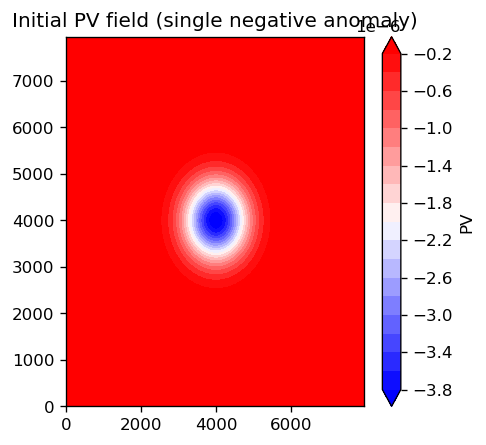

In [3]:
# ── Plot initial PV field ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.contourf(X, Y, q_init, 21, cmap="bwr", extend="both")
ax.set_title("Initial PV field (single negative anomaly)")
fig.colorbar(im, ax=ax, label="PV")
plt.show()


## 2  Basis construction pipeline: raw → pre-normed + smoothed → Gram-Schmidt

Three stages of the `compute_orthogonal_basis()` processing pipeline,
each shown as a 1 × 5 grid of the five fields (no Laplacian):

1. **Raw** input derivative fields (very different magnitudes)
2. **Pre-normalised + Gaussian-smoothed** (similar magnitudes, smooth)
3. **Gram-Schmidt orthogonalised** (orthogonal within the mask region)

In [18]:
# ── Build basis at t1 (with include_lap=False) ───────────────────
q1 = q_snaps[1]
gx1, gy1, gxx1, gyy1, gxy1 = derivs(q1)

SMOOTH_DEG = 3.0

basis = compute_orthogonal_basis(
    q1, gx1, gy1, x_deg, y_deg,
    pv_dx_dy=gxy1, pv_dx_dx=gxx1, pv_dy_dy=gyy1,
    mask="< -5e-8",
    apply_smoothing=True,
    smoothing_deg=SMOOTH_DEG,
    grid_spacing=GRID_DEG,
    include_lap=False,  # ← No Laplacian basis
)

print(f"Basis fields: {[f for f in dir(basis) if f.startswith('phi_')]}")
print(f"Grid shape: {basis.grid_shape}")
print(f"Mask points: {basis.mask.sum()} / {basis.mask.size}")

Basis fields: ['phi_def', 'phi_dx', 'phi_dy', 'phi_int', 'phi_lap', 'phi_strain']
Grid shape: (160, 160)
Mask points: 4144 / 25600


/tmp/ipykernel_2199078/803288596.py:7: UserWarning: compute_orthogonal_basis: grid_spacing=0.45045045045045046°, center_lat=60.0°N → dx(center)=24.9 km, dy=50.1 km
  basis = compute_orthogonal_basis(


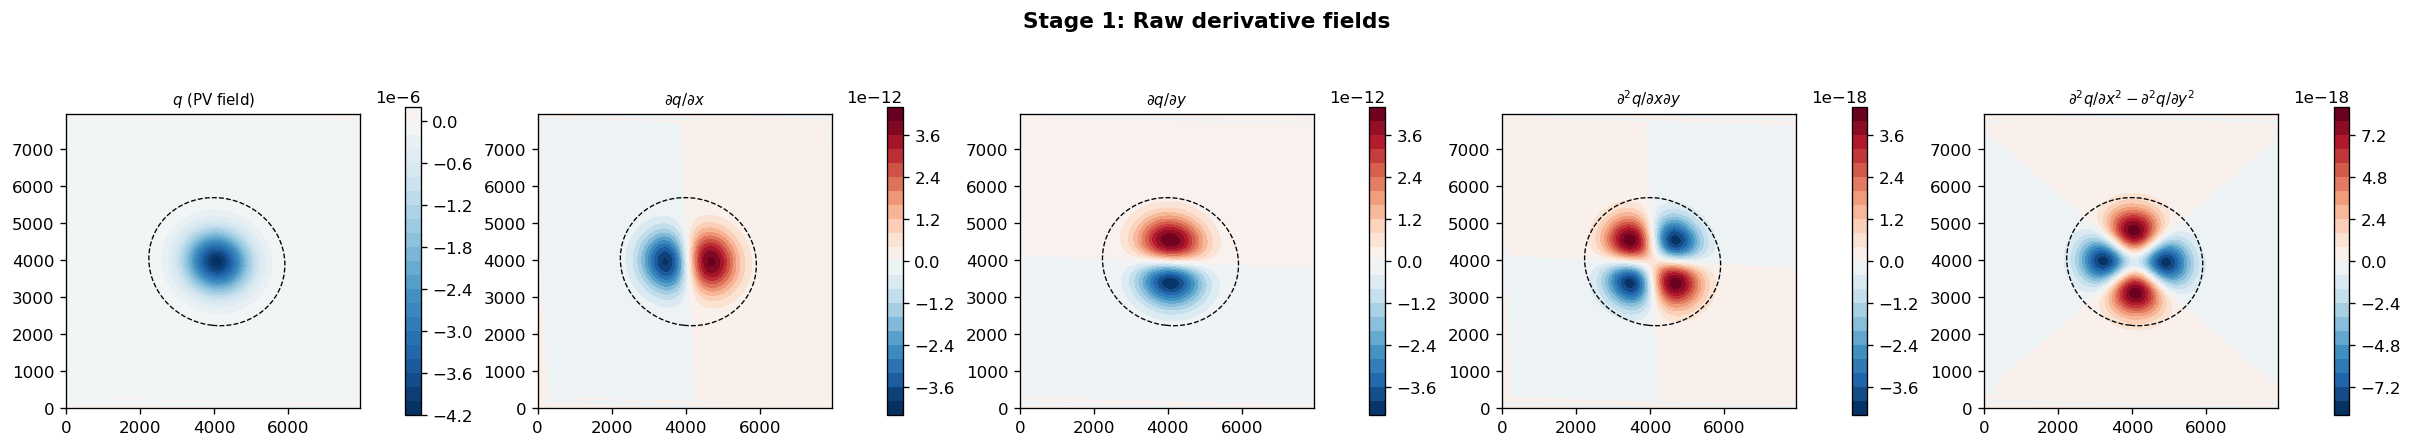

In [5]:
# ── Stage 1: Raw derivative fields (input to basis) ─────────────
raw_fields = [q1, gx1, gy1, gxy1, gxx1 - gyy1]
raw_labels = [r"$q$ (PV field)", r"$\partial q/\partial x$",
              r"$\partial q/\partial y$", r"$\partial^2 q/\partial x \partial y$",
              r"$\partial^2 q/\partial x^2 - \partial^2 q/\partial y^2$"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)
for ax, fld, lab in zip(axes.ravel(), raw_fields, raw_labels):
    vm = np.nanmax(np.abs(fld)) or 1.0
    im = ax.contourf(x_km, y_km, fld, 21, vmin=-vm, vmax=vm, cmap="RdBu_r")
    ax.contour(x_km, y_km, q1, levels=[-5e-8], colors="k",
               linewidths=0.8, linestyles="--")
    ax.set_aspect("equal"); ax.set_title(lab, fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle("Stage 1: Raw derivative fields", fontsize=13, fontweight="bold")
plt.show()

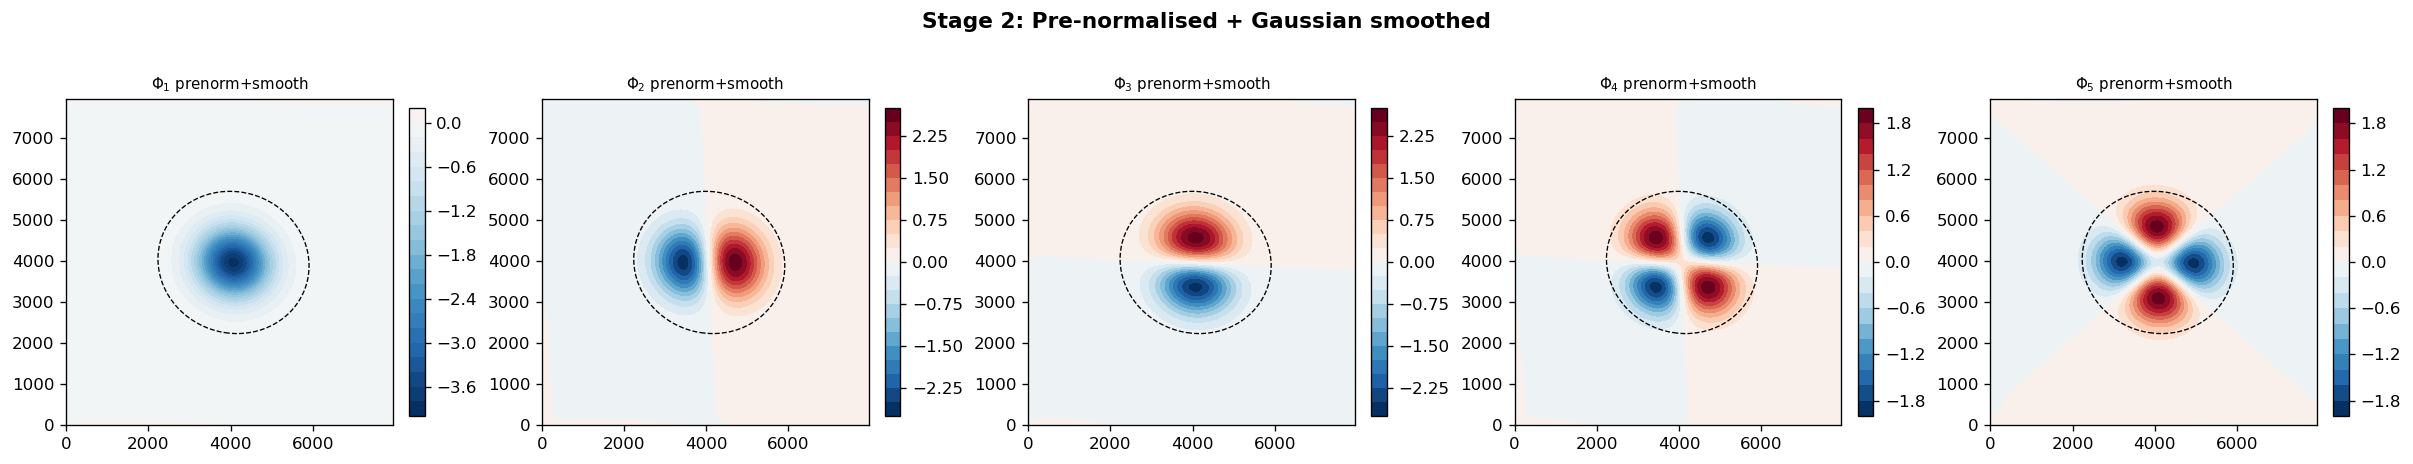

In [6]:
# ── Stage 2: Pre-normed + Gaussian smoothed (before GS) ─────────
pn = basis.scale_factors
prenormed = [q1 * pn["beta"], gx1 * pn["ax"], gy1 * pn["ay"],
             gxy1 * pn["gamma1"], (gxx1 - gyy1) * pn["gamma2"]]
smoothed = [gaussian_smooth_nan(f, SMOOTH_DEG, GRID_DEG) for f in prenormed]
ps_labels = [rf"$\Phi_{{{i+1}}}$ prenorm+smooth" for i in range(5)]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)
for ax, fld, lab in zip(axes.ravel(), smoothed, ps_labels):
    vm = np.nanmax(np.abs(fld)) or 1.0
    im = ax.contourf(x_km, y_km, fld, 21, vmin=-vm, vmax=vm, cmap="RdBu_r")
    ax.contour(x_km, y_km, q1, levels=[-5e-8], colors="k",
               linewidths=0.8, linestyles="--")
    ax.set_aspect("equal"); ax.set_title(lab, fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle("Stage 2: Pre-normalised + Gaussian smoothed", fontsize=13, fontweight="bold")
plt.show()

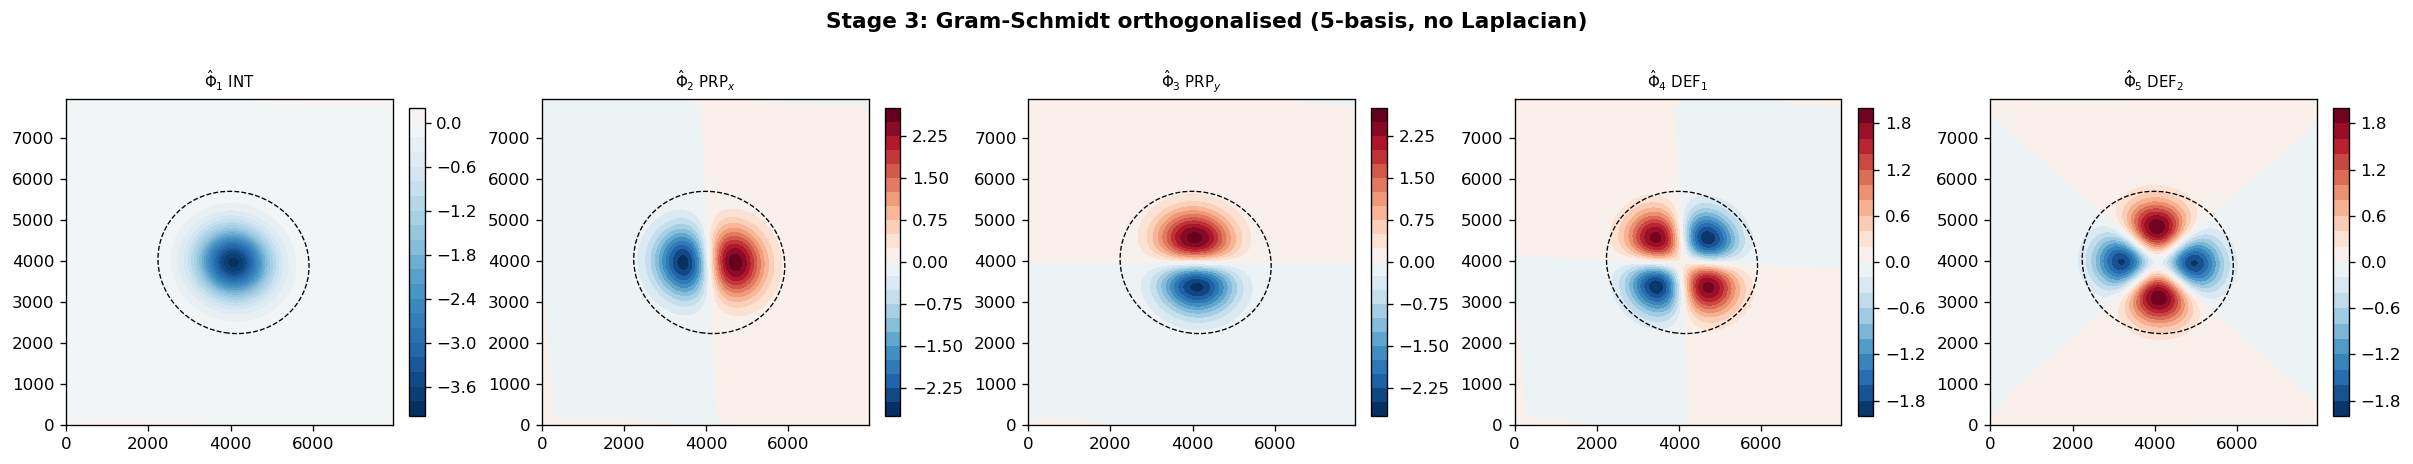

In [7]:
# ── Stage 3: Gram-Schmidt orthogonalised (final basis) ──────────
gs_fields = [basis.phi_int, basis.phi_dx, basis.phi_dy,
             basis.phi_def, basis.phi_strain]
gs_labels = [r"$\hat\Phi_1$ INT", r"$\hat\Phi_2$ PRP$_x$",
             r"$\hat\Phi_3$ PRP$_y$", r"$\hat\Phi_4$ DEF$_1$",
             r"$\hat\Phi_5$ DEF$_2$"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)
for ax, fld, lab in zip(axes.ravel(), gs_fields, gs_labels):
    vm = np.nanmax(np.abs(fld)) or 1.0
    im = ax.contourf(x_km, y_km, fld, 21, vmin=-vm, vmax=vm, cmap="RdBu_r")
    ax.contour(x_km, y_km, q1, levels=[-5e-8], colors="k",
               linewidths=0.8, linestyles="--")
    ax.set_aspect("equal"); ax.set_title(lab, fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle("Stage 3: Gram-Schmidt orthogonalised (5-basis, no Laplacian)", fontsize=13, fontweight="bold")
plt.show()

/tmp/ipykernel_2199078/135837423.py:4: UserWarning: compute_orthogonal_basis: grid_spacing=0.45045045045045046°, center_lat=60.0°N → dx(center)=24.9 km, dy=50.1 km
  basis0 = compute_orthogonal_basis(


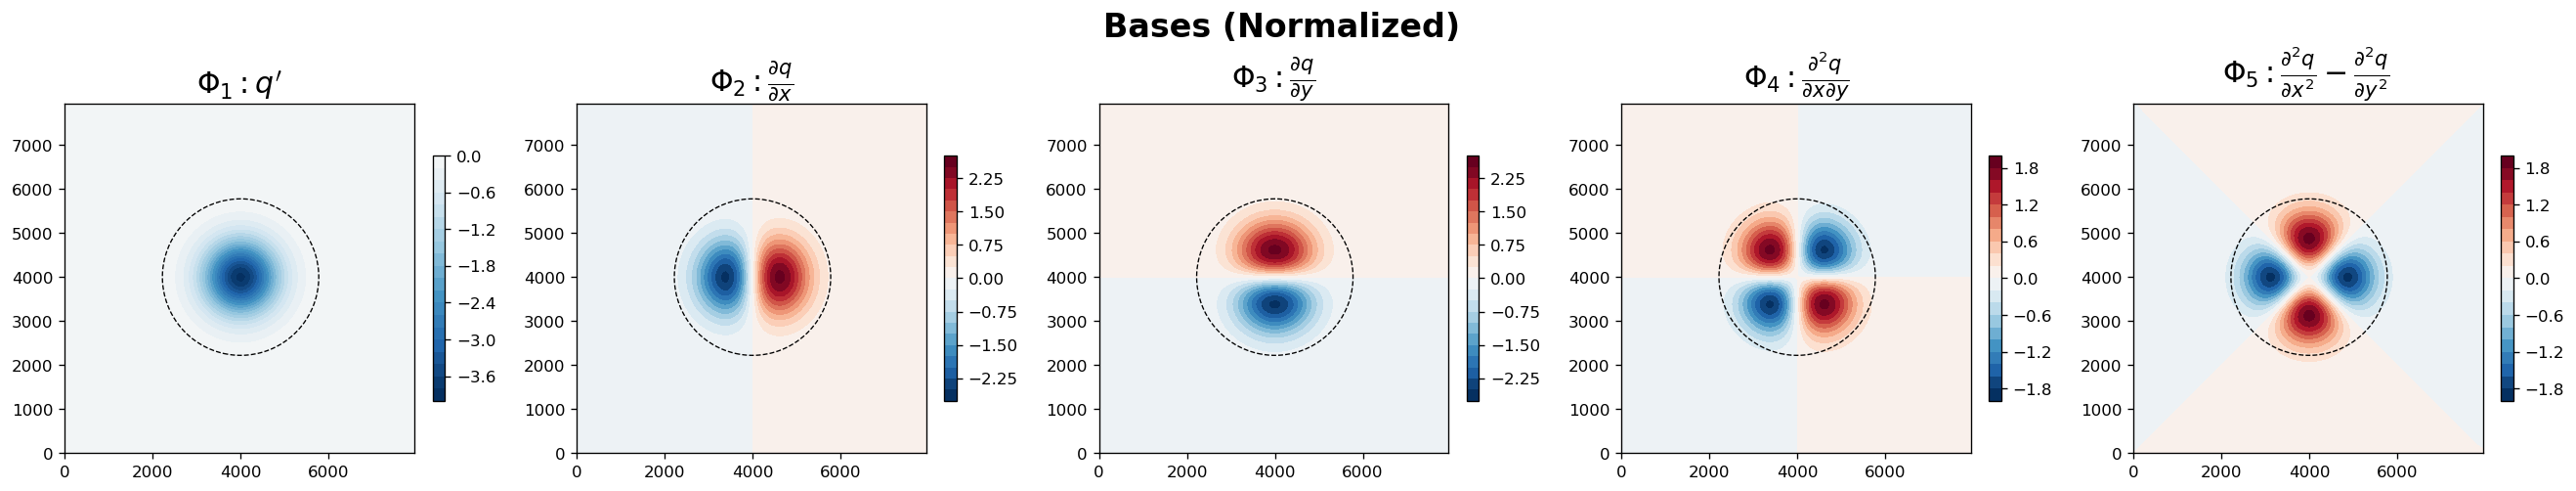

In [8]:
# ── Show basis fields at t0 ─────────────────────────────────────
q0 = q_snaps[0]
gx0, gy0, gxx0, gyy0, gxy0 = derivs(q0)
basis0 = compute_orthogonal_basis(
    q0, gx0, gy0, x_deg, y_deg,
    pv_dx_dy=gxy0, pv_dx_dx=gxx0, pv_dy_dy=gyy0,
    mask="< -5e-8",
    apply_smoothing=True,
    smoothing_deg=SMOOTH_DEG,
    grid_spacing=GRID_DEG,
    include_lap=False,
)
gs_fields0 = [basis0.phi_int, basis0.phi_dx, basis0.phi_dy, basis0.phi_def, basis0.phi_strain]
gs_labels0 = [r"$\Phi_1: q'$ ", r"$\Phi_2: \frac{\partial q}{\partial x}$", r"$\Phi_3: \frac{\partial q}{\partial y}$", 
              r"$\Phi_4: \frac{\partial^2 q}{\partial x \partial y}$", r"$\Phi_5: \frac{\partial^2 q}{\partial x^2}- \frac{\partial^2 q}{\partial y^2}$ "]

fig, axes = plt.subplots(1, 5, figsize=(22, 4), constrained_layout=True)
for ax, fld, lab in zip(axes.ravel(), gs_fields0, gs_labels0):
    vm = np.nanmax(np.abs(fld)) or 1.0
    im = ax.contourf(x_km, y_km, fld, 21, vmin=-vm, vmax=vm, cmap="RdBu_r")
    ax.contour(x_km, y_km, q0, levels=[-5e-8], colors="k", linewidths=0.8, linestyles="--")
    ax.set_aspect("equal"); ax.set_title(lab, fontsize=18)
    plt.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle("Bases (Normalized)", fontsize=20, fontweight="bold")
plt.show()


## 3  Projection at $t_1$: Prescribed vs Diagnosed coefficients

In [19]:
# ── Project dq/dt at t1 onto basis ────────────────────────────────
res1 = project_field(dqdt_1, basis)

print("="*60)
print("Timestep 1 (t=1h): Prescribed vs Diagnosed coefficients")
print("="*60)
print(f"{'Coeff':<10} {'Prescribed':>15} {'Diagnosed':>15} {'Error %':>12}")
print("-"*60)
for name, true_val, diag_key in [
    ("β", BETA, "beta"),
    ("αx", AX, "ax"),
    ("αy", AY, "ay"),
    ("γ₁", G1, "gamma1"),
    ("γ₂", G2, "gamma2"),
]:
    diag_val = res1[diag_key]
    err_pct = 100 * (diag_val - true_val) / abs(true_val) if true_val != 0 else 0
    print(f"{name:<10} {true_val:>15.4e} {diag_val:>15.4e} {err_pct:>11.2f}%")
print("-"*60)
print(f"RMSE = {res1['rmse']:.4e}")

Timestep 1 (t=1h): Prescribed vs Diagnosed coefficients
Coeff           Prescribed       Diagnosed      Error %
------------------------------------------------------------
β               1.0000e-05      1.1071e-05       10.71%
αx              2.0000e+01      2.0494e+01        2.47%
αy             -1.0000e+01     -1.0522e+01       -5.22%
γ₁              4.8000e+06      5.2504e+06        9.38%
γ₂             -3.0000e+06     -3.2524e+06       -8.41%
------------------------------------------------------------
RMSE = 1.4886e-12


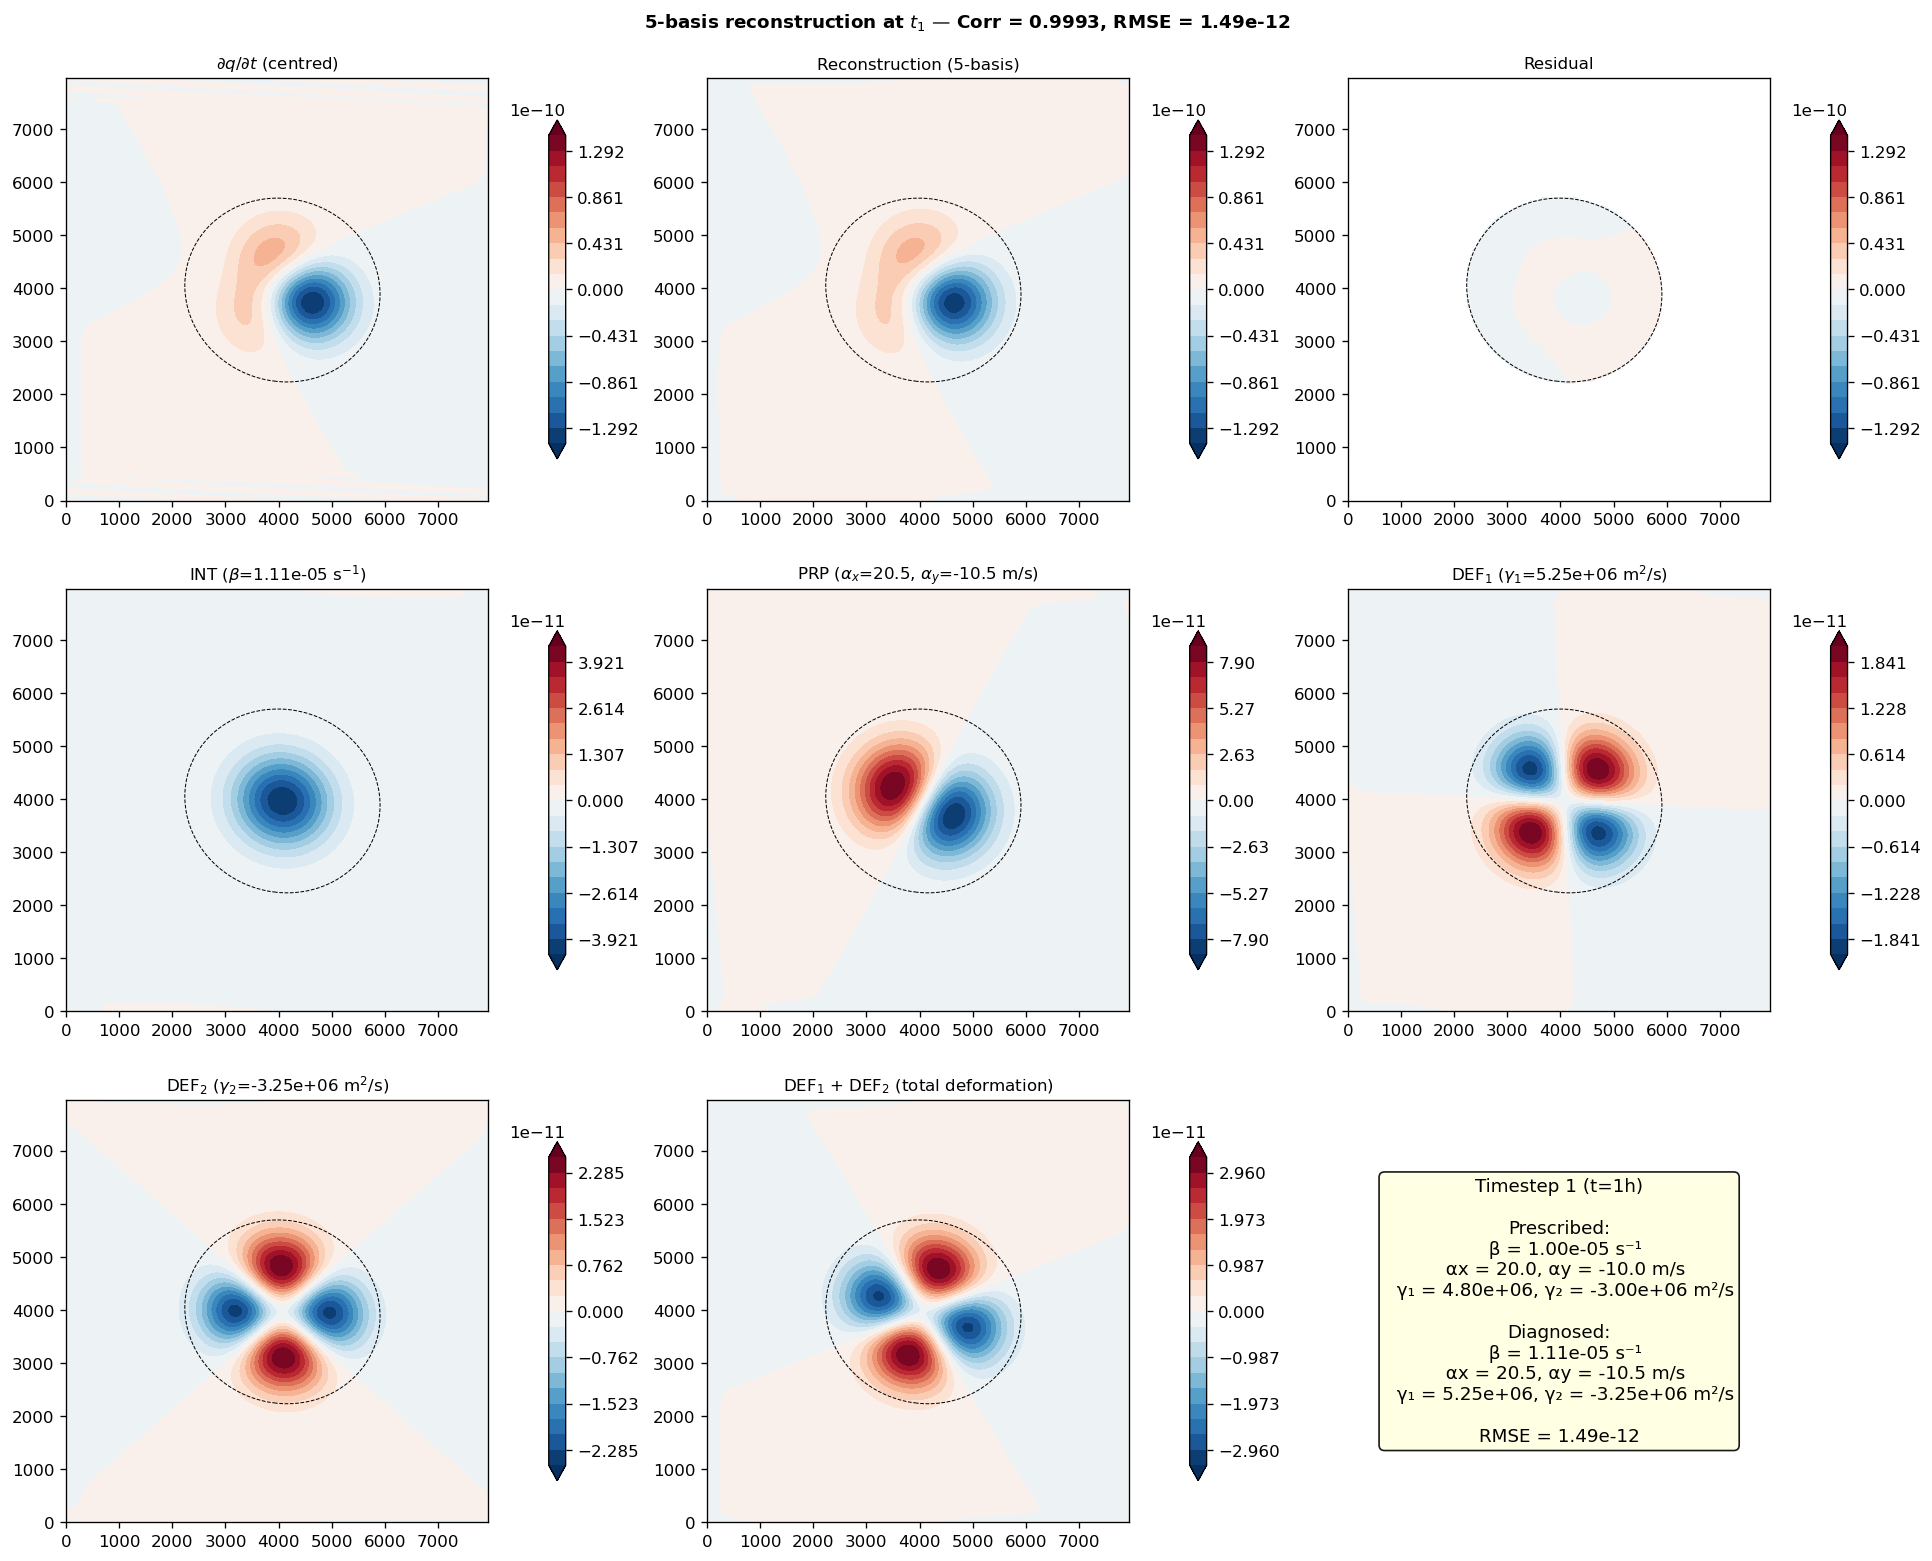

In [26]:
# ── 3×3 panels for t1 ─────────────────────────────────────────────
def zero_centered_levels(field, n=21):
    vm = np.nanmax(np.abs(field))
    if not np.isfinite(vm) or vm == 0:
        vm = 1e-30
    return np.linspace(-vm, vm, n), vm

vm_top = np.nanmax(np.abs(dqdt_1))
panels = [
    (dqdt_1,        r"$\partial q/\partial t$ (centred)", vm_top),
    (res1["recon"], r"Reconstruction (5-basis)",          vm_top),
    (res1["resid"], r"Residual",                          vm_top),
    (res1["int"],   rf"INT ($\beta$={res1['beta']:.2e} s$^{{-1}}$)",              None),
    (res1["prop"],  rf"PRP ($\alpha_x$={res1['ax']:.1f}, $\alpha_y$={res1['ay']:.1f} m/s)", None),
    (res1["def1"],  rf"DEF$_1$ ($\gamma_1$={res1['gamma1']:.2e} m$^2$/s)",       None),
    (res1["def2"],  rf"DEF$_2$ ($\gamma_2$={res1['gamma2']:.2e} m$^2$/s)",       None),
    (res1["def"],   r"DEF$_1$ + DEF$_2$ (total deformation)",                    None),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13), constrained_layout=True)
for ax, (fld, lab, vm_fixed) in zip(axes.ravel()[:len(panels)], panels):
    if vm_fixed is None:
        levels, vm = zero_centered_levels(fld)
    else:
        vm = vm_fixed if np.isfinite(vm_fixed) and vm_fixed != 0 else 1e-30
        levels = np.linspace(-vm, vm, 21)
    im = ax.contourf(x_km, y_km, fld, levels=levels, cmap="RdBu_r", extend="both")
    ax.contour(x_km, y_km, q1, levels=[-5e-8], colors="k",
               linewidths=0.6, linestyles="--")
    ax.set_aspect("equal"); ax.set_title(lab, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.75)

# Last panel: info box
axes[2,2].axis("off")
axes[2,2].text(0.5, 0.5,
    f"Timestep 1 (t=1h)\n\n"
    f"Prescribed:\n"
    f"  β = {BETA:.2e} s⁻¹\n"
    f"  αx = {AX:.1f}, αy = {AY:.1f} m/s\n"
    f"  γ₁ = {G1:.2e}, γ₂ = {G2:.2e} m²/s\n\n"
    f"Diagnosed:\n"
    f"  β = {res1['beta']:.2e} s⁻¹\n"
    f"  αx = {res1['ax']:.1f}, αy = {res1['ay']:.1f} m/s\n"
    f"  γ₁ = {res1['gamma1']:.2e}, γ₂ = {res1['gamma2']:.2e} m²/s\n\n"
    f"RMSE = {res1['rmse']:.2e}",
    transform=axes[2,2].transAxes, fontsize=11,
    ha="center", va="center",
    bbox=dict(boxstyle="round", fc="lightyellow", alpha=0.9))

corr = np.corrcoef(dqdt_1[basis.mask & np.isfinite(dqdt_1)],
                    res1["recon"][basis.mask & np.isfinite(res1["recon"])])[0, 1]
fig.suptitle(
    rf"5-basis reconstruction at $t_1$ — Corr = {corr:.4f}, RMSE = {res1['rmse']:.2e}",
    fontsize=11, fontweight="bold")
plt.show()

## 4  Projection at $t_2$: Prescribed vs Diagnosed coefficients

In [20]:
# ── Build basis at t2 ────────────────────────────────────────────
q2 = q_snaps[2]
gx2, gy2, gxx2, gyy2, gxy2 = derivs(q2)

basis2 = compute_orthogonal_basis(
    q2, gx2, gy2, x_deg, y_deg,
    pv_dx_dy=gxy2, pv_dx_dx=gxx2, pv_dy_dy=gyy2,
    mask="< -5e-8",
    apply_smoothing=True,
    smoothing_deg=SMOOTH_DEG,
    grid_spacing=GRID_DEG,
    include_lap=False,
)

# ── Project dq/dt at t2 onto basis ────────────────────────────────
res2 = project_field(dqdt_2, basis2)

print("="*60)
print("Timestep 2 (t=2h): Prescribed vs Diagnosed coefficients")
print("="*60)
print(f"{'Coeff':<10} {'Prescribed':>15} {'Diagnosed':>15} {'Error %':>12}")
print("-"*60)
for name, true_val, diag_key in [
    ("β", BETA, "beta"),
    ("αx", AX, "ax"),
    ("αy", AY, "ay"),
    ("γ₁", G1, "gamma1"),
    ("γ₂", G2, "gamma2"),
]:
    diag_val = res2[diag_key]
    err_pct = 100 * (diag_val - true_val) / abs(true_val) if true_val != 0 else 0
    print(f"{name:<10} {true_val:>15.4e} {diag_val:>15.4e} {err_pct:>11.2f}%")
print("-"*60)
print(f"RMSE = {res2['rmse']:.4e}")

Timestep 2 (t=2h): Prescribed vs Diagnosed coefficients
Coeff           Prescribed       Diagnosed      Error %
------------------------------------------------------------
β               1.0000e-05      1.1894e-05       18.94%
αx              2.0000e+01      1.9900e+01       -0.50%
αy             -1.0000e+01     -1.0526e+01       -5.26%
γ₁              4.8000e+06      5.4003e+06       12.51%
γ₂             -3.0000e+06     -3.2823e+06       -9.41%
------------------------------------------------------------
RMSE = 1.5895e-12


/tmp/ipykernel_2199078/2945585959.py:5: UserWarning: compute_orthogonal_basis: grid_spacing=0.45045045045045046°, center_lat=60.0°N → dx(center)=24.9 km, dy=50.1 km
  basis2 = compute_orthogonal_basis(


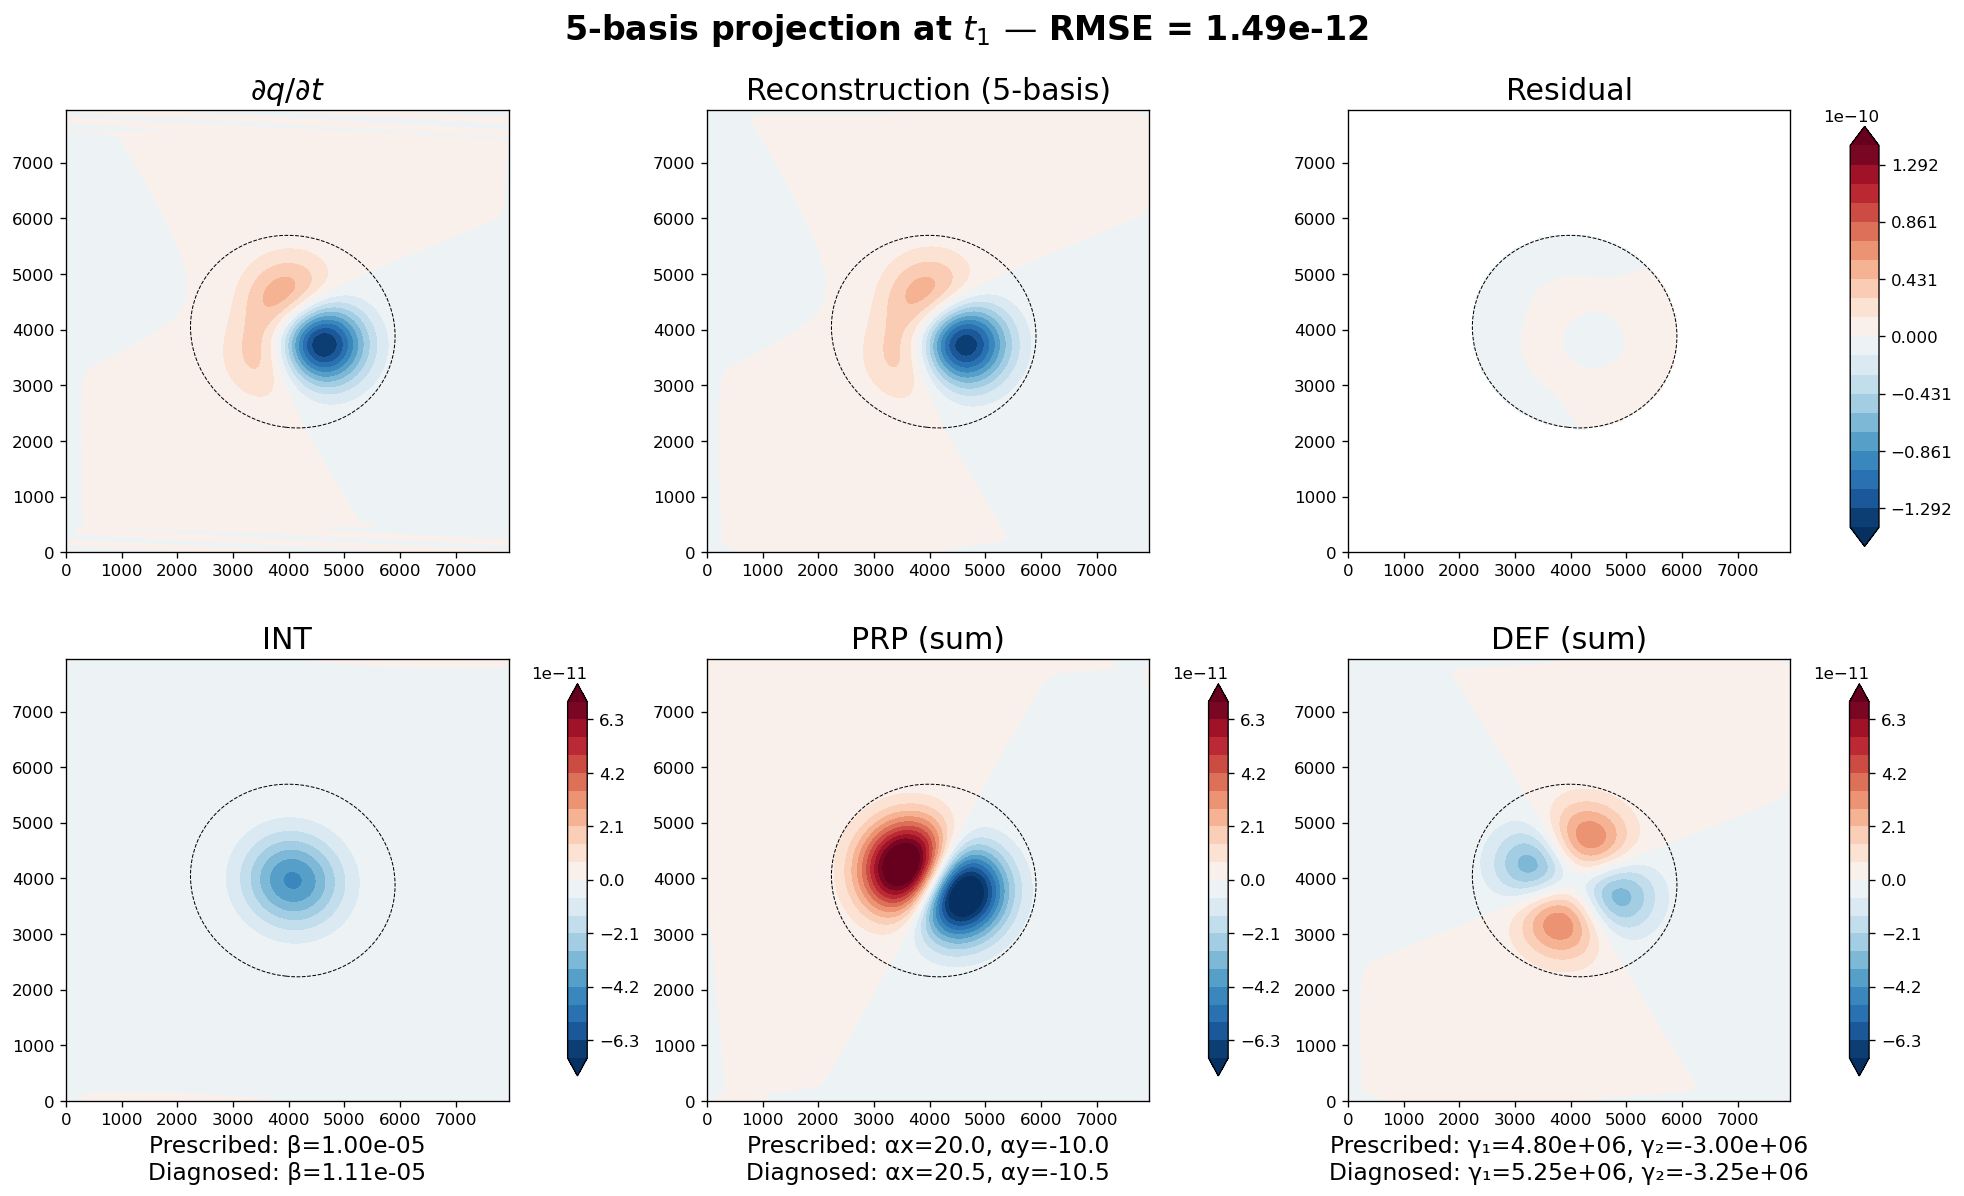

In [28]:
# ── 2×3 panels for t1: pv_dt, recon, resid; int, prp, def ─────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

# Shared zero-centered colorbar range for top row
vm_shared = np.nanmax(np.abs(dqdt_1))
if not np.isfinite(vm_shared) or vm_shared == 0:
    vm_shared = 1e-30
levels_shared = np.linspace(-vm_shared, vm_shared, 21)

# Top row: dqdt_1, reconstruction, residual (shared colorbar)
fields_top = [
    (dqdt_1, r"$\partial q/\partial t$ "),
    (res1["recon"], r"Reconstruction (5-basis)"),
    (res1["resid"], r"Residual")
]
ims_top = []
for i, (fld, lab) in enumerate(fields_top):
    ax = axes[0, i]
    im = ax.contourf(x_km, y_km, fld, levels=levels_shared, cmap="RdBu_r", extend="both")
    ax.contour(x_km, y_km, q1, levels=[-5e-8], colors="k", linewidths=0.6, linestyles="--")
    ax.set_aspect("equal"); ax.set_title(lab, fontsize=18)
    ims_top.append(im)

# Shared colorbar for top row
cbar_ax = fig.add_axes([0.96, 0.55, 0.015, 0.35])
fig.colorbar(ims_top[0], cax=cbar_ax)

# Bottom row: int, prp, def with prescribed vs diagnosed in subtitles
fields_bot = [
    (res1["int"], r"INT", f"Prescribed: β={BETA:.2e}\nDiagnosed: β={res1['beta']:.2e}"),
    (res1["prop"], r"PRP (sum)", f"Prescribed: αx={AX:.1f}, αy={AY:.1f}\nDiagnosed: αx={res1['ax']:.1f}, αy={res1['ay']:.1f}"),
    (res1["def"], r"DEF (sum)", f"Prescribed: γ₁={G1:.2e}, γ₂={G2:.2e}\nDiagnosed: γ₁={res1['gamma1']:.2e}, γ₂={res1['gamma2']:.2e}")
]
for i, (fld, lab, sub) in enumerate(fields_bot):
    ax = axes[1, i]
    vm = np.nanmax(np.abs(fld))
    if not np.isfinite(vm) or vm == 0:
        vm = 1e-30
    # levels = np.linspace(-vm, vm, 21)
    levels = np.linspace(-7e-11, 7e-11, 21)
    im = ax.contourf(x_km, y_km, fld, levels=levels, cmap="RdBu_r", extend="both")
    ax.contour(x_km, y_km, q1, levels=[-5e-8], colors="k", linewidths=0.6, linestyles="--")
    ax.set_aspect("equal"); ax.set_title(lab, fontsize=18)
    ax.set_xlabel(sub, fontsize=14)
    plt.colorbar(im, ax=ax, shrink=0.75)

fig.suptitle(rf"5-basis projection at $t_1$ — RMSE = {res1['rmse']:.2e}", fontsize=20, fontweight="bold")
plt.show()

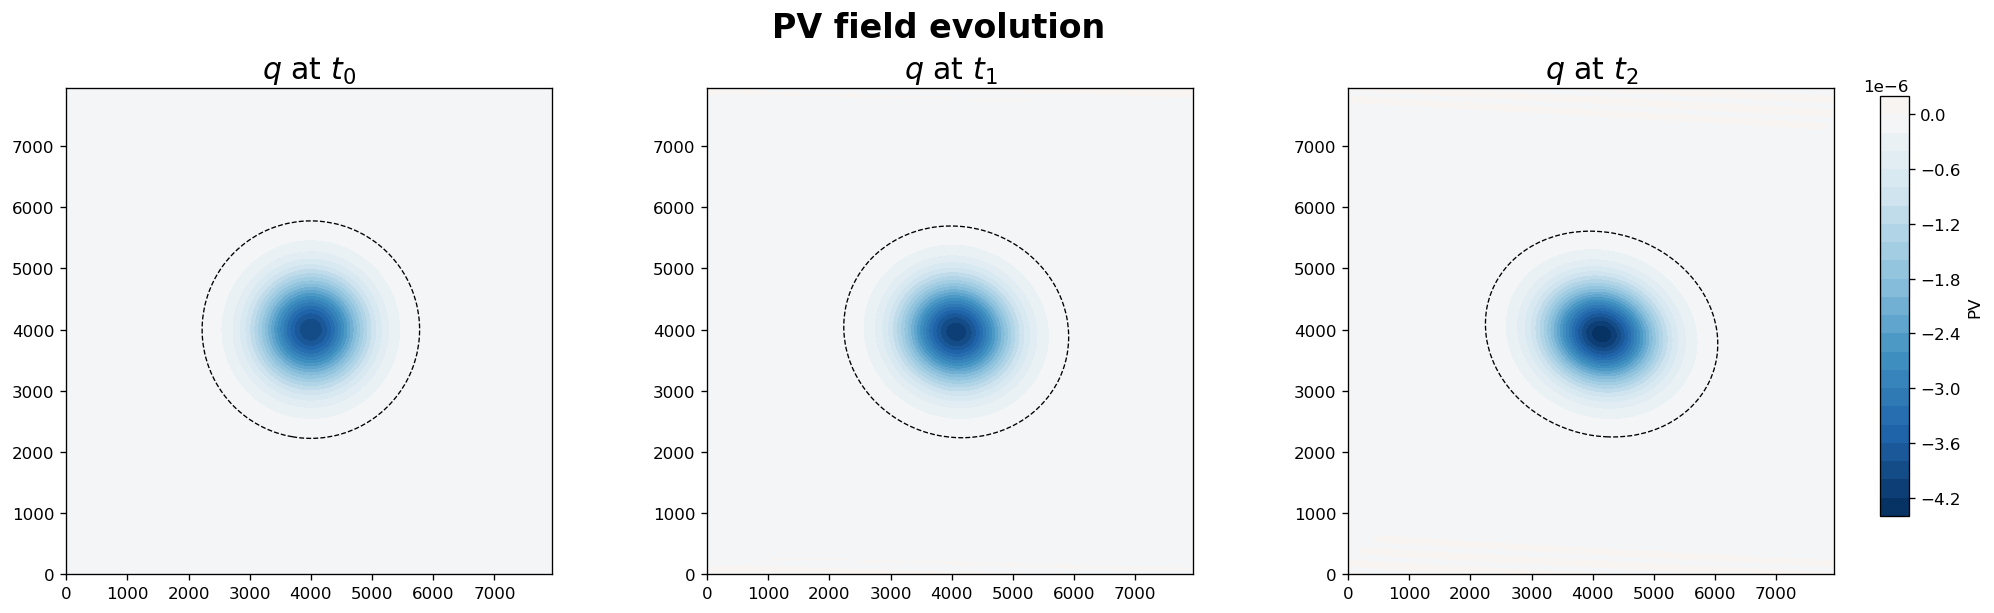

In [22]:
# ── 3 panels: PV evolution at t0, t1, t2 ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

pv_snaps = [q_snaps[0], q_snaps[1], q_snaps[2]]
pv_labels = [r"$q$ at $t_0$", r"$q$ at $t_1$", r"$q$ at $t_2$"]
vm_pv = np.nanmax(np.abs(np.stack(pv_snaps)))

for ax, fld, lab in zip(axes, pv_snaps, pv_labels):
    im = ax.contourf(x_km, y_km, fld, 21, vmin=-vm_pv, vmax=vm_pv, cmap="RdBu_r")
    ax.contour(x_km, y_km, fld, levels=[-5e-8], colors="k", linewidths=0.8, linestyles="--")
    ax.set_aspect("equal"); ax.set_title(lab, fontsize=18)

# Shared colorbar
cbar_ax = fig.add_axes([0.99, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="PV")
fig.suptitle("PV field evolution", fontsize=20, fontweight="bold")
plt.show()


## 5  Summary: Prescribed vs Diagnosed coefficients for both timesteps

In [14]:
# ── Summary comparison table ─────────────────────────────────────
import pandas as pd

summary = pd.DataFrame({
    "Coefficient": ["β (s⁻¹)", "αx (m/s)", "αy (m/s)", "γ₁ (m²/s)", "γ₂ (m²/s)"],
    "Prescribed": [BETA, AX, AY, G1, G2],
    "Diag t1": [res1["beta"], res1["ax"], res1["ay"], res1["gamma1"], res1["gamma2"]],
    "Diag t2": [res2["beta"], res2["ax"], res2["ay"], res2["gamma1"], res2["gamma2"]],
})

summary["Err t1 (%)"] = 100 * (summary["Diag t1"] - summary["Prescribed"]) / np.abs(summary["Prescribed"])
summary["Err t2 (%)"] = 100 * (summary["Diag t2"] - summary["Prescribed"]) / np.abs(summary["Prescribed"])

display(summary.style.format({
    "Prescribed": "{:.4e}",
    "Diag t1": "{:.4e}",
    "Diag t2": "{:.4e}",
    "Err t1 (%)": "{:.2f}",
    "Err t2 (%)": "{:.2f}",
}))

print(f"\nRMSE t1 = {res1['rmse']:.4e}")
print(f"RMSE t2 = {res2['rmse']:.4e}")

,Coefficient,Prescribed,Diag t1,Diag t2,Err t1 (%),Err t2 (%)
0,β (s⁻¹),1.0000e-05,1.1071e-05,1.1894e-05,10.71,18.94
1,αx (m/s),2.0000e+01,2.0494e+01,1.9900e+01,2.47,-0.50
2,αy (m/s),-1.0000e+01,-1.0522e+01,-1.0526e+01,-5.22,-5.26
3,γ₁ (m²/s),4.8000e+06,5.2504e+06,5.4003e+06,9.38,12.51
4,γ₂ (m²/s),-3.0000e+06,-3.2524e+06,-3.2823e+06,-8.41,-9.41



RMSE t1 = 1.4886e-12
RMSE t2 = 1.5895e-12


## 6  Reanalysis application: 1260 blocking onset composite (dh=0)

Apply the same 5-basis decomposition to the **real ERA5 composite** of 1260 blocking onset
events at dh=0 (loaded from `onset_composite_wavg.pkl`). The target tendency field is
`pv_dt`, and the basis is built from the composite PV-anomaly derivatives.


In [31]:
# ── Load 1260-event blocking onset composite (dh=0) ──────────────
import pickle
from pathlib import Path

PKL_PATH = Path("/net/flood/data2/users/x_yan/pvtend/outputs/blocking/composite.pkl")
with open(PKL_PATH, "rb") as f:
    COMP = pickle.load(f)

# CompositeResult API: reduce_2d(field, stage, dh, variant=..., level_mode="wavg")
STAGE = "onset"
DH = 0
VARIANT = "original"   # all 1260 events
LEVEL_MODE = "200"    # exp(-z/H) weighted avg over 300/250/200 hPa

def c2d(field):
    return COMP.reduce_2d(field, STAGE, DH, variant=VARIANT, level_mode=LEVEL_MODE)

X_rel = COMP.x_rel
Y_rel = COMP.y_rel
x_rel = X_rel[0, :] if X_rel.ndim == 2 else X_rel
y_rel = Y_rel[:, 0] if Y_rel.ndim == 2 else Y_rel
GRID_SP = float(np.abs(x_rel[1] - x_rel[0]))
SMOOTH_DEG_R = 3.0

# Fields in composite_blocking.pkl have "_3d" suffix
pv_anom = c2d("pv_anom_3d")
pv_dx   = c2d("pv_anom_dx_3d")
pv_dy   = c2d("pv_anom_dy_3d")
pv_dxdx = c2d("pv_dx_dx_3d")
pv_dxdy = c2d("pv_dx_dy_3d")
pv_dydy = c2d("pv_dy_dy_3d")
pv_dt   = c2d("pv_dt_3d")   # full PV tendency (not anomaly)

n_events = COMP.counts.get(STAGE, {}).get(DH, 0) if VARIANT == "original" \
           else COMP.counts_v.get(VARIANT, {}).get(STAGE, {}).get(DH, 0)

print(f"Composite loaded: variant={VARIANT}, stage={STAGE}, dh={DH:+d}, level={LEVEL_MODE}")
print(f"  n_events = {n_events}")
print(f"  Grid shape: {pv_anom.shape}, spacing = {GRID_SP}°")
print(f"  pv_anom range: [{np.nanmin(pv_anom):.2e}, {np.nanmax(pv_anom):.2e}]")
print(f"  pv_dt range: [{np.nanmin(pv_dt):.2e}, {np.nanmax(pv_dt):.2e}]")

# ── Build 5-basis (no Laplacian) ─────────────────────────────────
basis_r = compute_orthogonal_basis(
    pv_anom, pv_dx, pv_dy, x_rel, y_rel,
    pv_dx_dx=pv_dxdx, pv_dx_dy=pv_dxdy, pv_dy_dy=pv_dydy,
    mask="< 0",
    apply_smoothing=True,
    smoothing_deg=SMOOTH_DEG_R,
    grid_spacing=GRID_SP,
    include_lap=False,
    interp_alpha=1,
)

# ── Project pv_dt onto the basis ─────────────────────────────────
res_r = project_field(pv_dt, basis_r)

print("\n" + "="*60)
print(f"Reanalysis diagnosed coefficients ({n_events} onset events, dh=0)")
print("="*60)
print(f"  β       = {res_r['beta']:.4e} s⁻¹")
print(f"  αx      = {res_r['ax']:.4f} m/s")
print(f"  αy      = {res_r['ay']:.4f} m/s")
print(f"  γ₁      = {res_r['gamma1']:.4e} m²/s")
print(f"  γ₂      = {res_r['gamma2']:.4e} m²/s")
print(f"  RMSE    = {res_r['rmse']:.4e}")


Composite loaded: variant=original, stage=onset, dh=+0, level=200
  n_events = 1260
  Grid shape: (29, 49), spacing = 1.5°
  pv_anom range: [-2.79e-06, 6.79e-07]
  pv_dt range: [-3.28e-11, 1.66e-11]

Reanalysis diagnosed coefficients (1260 onset events, dh=0)
  β       = 4.8850e-06 s⁻¹
  αx      = 5.5256 m/s
  αy      = 2.0319 m/s
  γ₁      = 4.4535e+05 m²/s
  γ₂      = 2.1817e+05 m²/s
  RMSE    = 3.8646e-12


/tmp/ipykernel_2199078/1454368869.py:44: UserWarning: compute_orthogonal_basis: grid_spacing=1.5°, center_lat=60.0°N → dx(center)=83.4 km, dy=166.8 km
  basis_r = compute_orthogonal_basis(


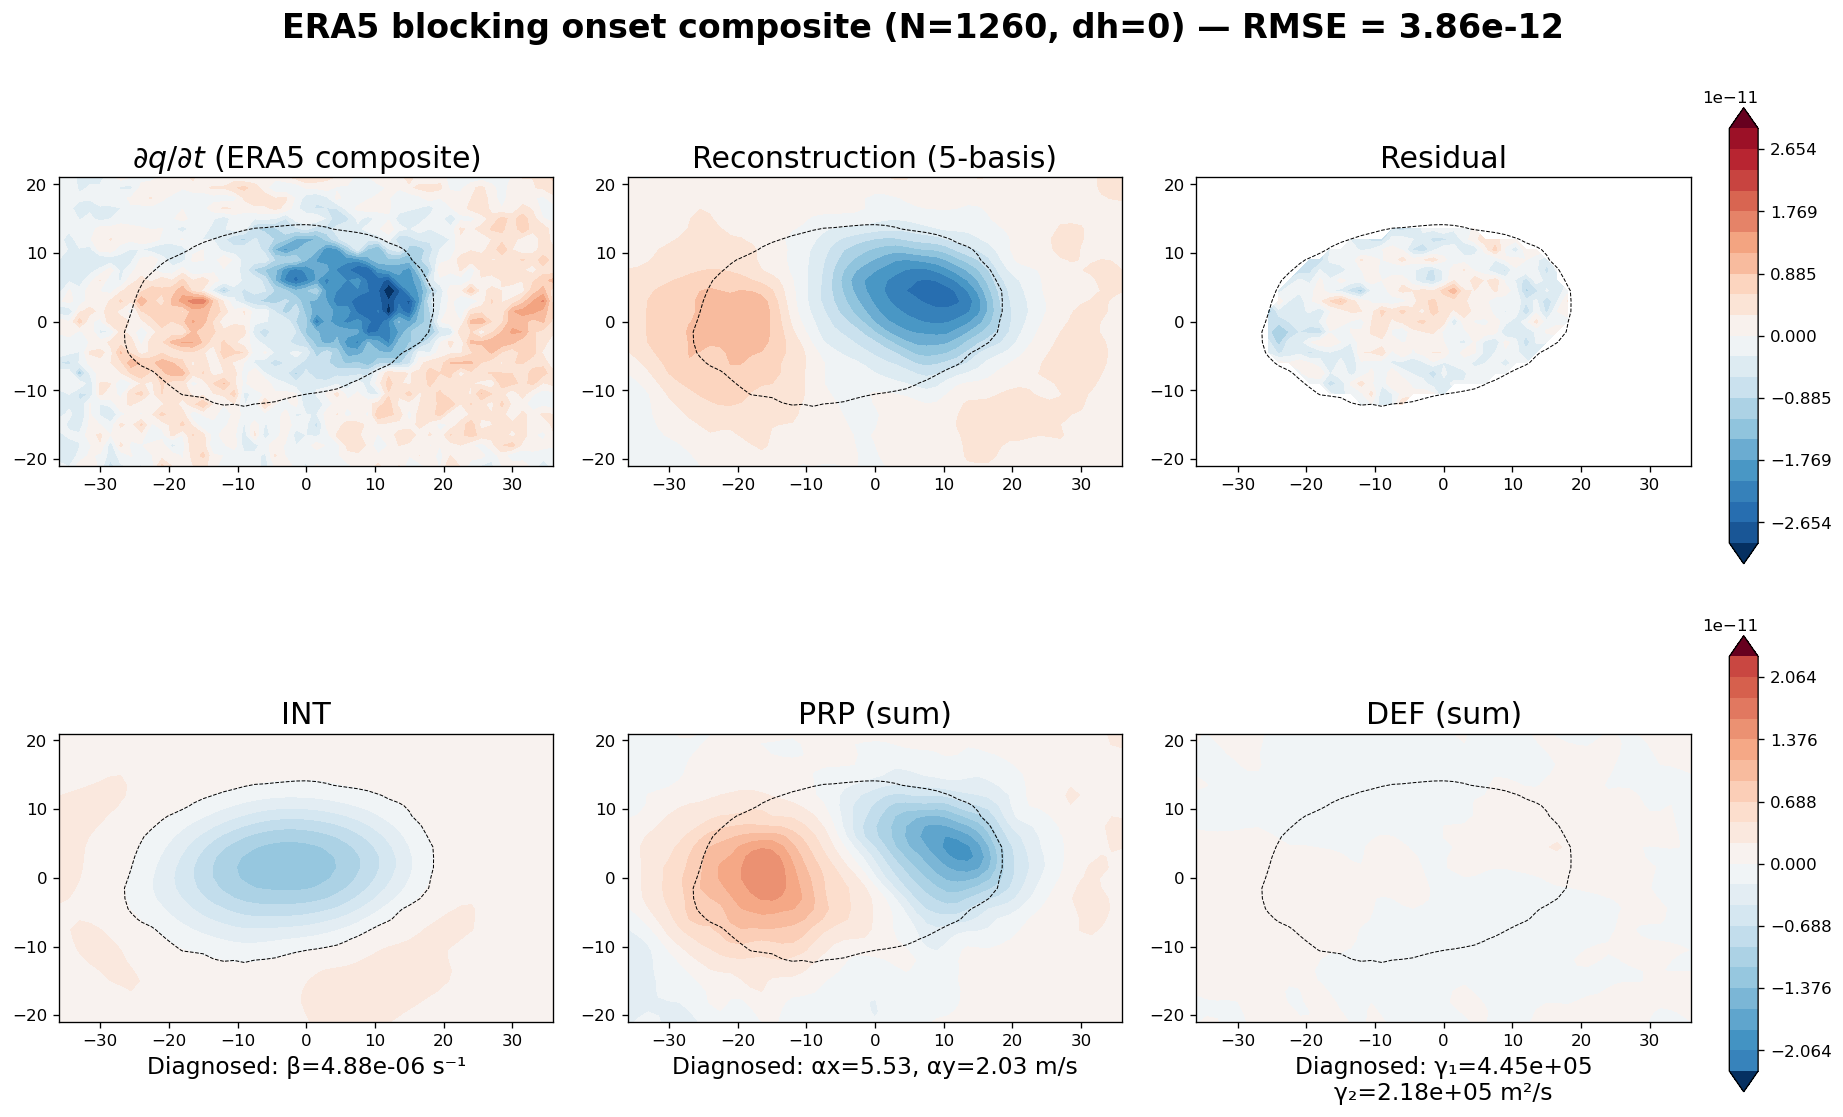

In [35]:
# ── 2×3 panels for reanalysis: pv_dt, recon, resid; int, prp, def ────
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=False)

vm_shared = np.nanmax(np.abs(pv_dt))
levels_shared = np.linspace(-0.9*vm_shared, 0.9*vm_shared, 21)
levels_shared_half = np.linspace(-0.7*vm_shared, 0.7*vm_shared, 21)

# Top row: pv_dt, reconstruction, residual (shared colorbar)
fields_top = [
    (pv_dt, r"$\partial q/\partial t$ (ERA5 composite)"),
    (res_r["recon"], r"Reconstruction (5-basis)"),
    (res_r["resid"], r"Residual"),
]
ims_top = []
for i, (fld, lab) in enumerate(fields_top):
    ax = axes[0, i]
    im = ax.contourf(x_rel, y_rel, fld, levels=levels_shared,
                     vmin=-vm_shared, vmax=vm_shared, cmap="RdBu_r", extend="both")
    ax.contour(x_rel, y_rel, pv_anom, levels=[0], colors="k", linewidths=0.6, linestyles="--")
    ax.set_aspect("equal"); ax.set_title(lab, fontsize=18)
    ims_top.append(im)

# Bottom row: INT, PRP, DEF with diagnosed values as subtitles — SAME colorbar range as top
fields_bot = [
    (res_r["int"],  r"INT",       f"Diagnosed: β={res_r['beta']:.2e} s⁻¹"),
    (res_r["prop"], r"PRP (sum)", f"Diagnosed: αx={res_r['ax']:.2f}, αy={res_r['ay']:.2f} m/s"),
    (res_r["def"],  r"DEF (sum)", f"Diagnosed: γ₁={res_r['gamma1']:.2e}\nγ₂={res_r['gamma2']:.2e} m²/s"),
]
ims_bot = []
for i, (fld, lab, sub) in enumerate(fields_bot):
    ax = axes[1, i]
    im = ax.contourf(x_rel, y_rel, fld, levels=levels_shared_half,
                     vmin=-vm_shared, vmax=vm_shared, cmap="RdBu_r", extend="both")
    ax.contour(x_rel, y_rel, pv_anom, levels=[0], colors="k", linewidths=0.6, linestyles="--")
    ax.set_aspect("equal"); ax.set_title(lab, fontsize=18)
    ax.set_xlabel(sub, fontsize=14)
    ims_bot.append(im)

fig.subplots_adjust(left=0.05, right=0.9, top=0.90, bottom=0.08, wspace=0.15, hspace=0.3)
cbar_ax_top = fig.add_axes([0.92, 0.52, 0.015, 0.38])
fig.colorbar(ims_top[0], cax=cbar_ax_top)
cbar_ax_bot = fig.add_axes([0.92, 0.08, 0.015, 0.38])
fig.colorbar(ims_bot[0], cax=cbar_ax_bot)

fig.suptitle(
    rf"ERA5 blocking onset composite (N={n_events}, dh=0) — RMSE = {res_r['rmse']:.2e}",
    fontsize=20, fontweight="bold")
plt.show()


In [34]:
1

1